# Capstone Two: Modeling
## Class A/B/C Multifamily Risk Score in USA
Author: Daksha Gummadi

This notebook builds machine learning models to predict year over year rent growth for multifamily properties across the United States. The goal is to use market indicators to predict the column rent_growth_yoy. Since rent growth is a number and not a category this is a regression problem. I will build three different models, compare them using the same metrics and pick the best one.

## Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load and Prepare Data](#2-load-and-prepare-data)
3. [Add New Economic Features](#3-add-new-economic-features)
4. [Sliding Window Data Augmentation](#4-sliding-window-data-augmentation)
5. [Train and Test Split](#5-train-and-test-split)
6. [Model 1: Linear Regression Baseline](#6-model-1-linear-regression-baseline)
7. [Model 2: Ridge Regression Regularized Linear](#7-model-2-ridge-regression-regularized-linear)
8. [Model 3: Random Forest with Hyperparameter Tuning](#8-model-3-random-forest-with-hyperparameter-tuning)
9. [Model Comparison and Final Selection](#9-model-comparison-and-final-selection)
10. [Conclusion](#10-conclusion)

## 1. Import Libraries

Here I bring in all the tools I need to build and evaluate my models. Pandas and numpy handle the data. Matplotlib makes the charts. From sklearn I import the three models I will use plus tools for scaling the features, running cross validation, tuning hyperparameters, and measuring how well each model performs.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 2. Load and Prepare Data

I load the cleaned dataset that was saved at the end of the Data Wrangling step. This file has one row per month from January 2020 to December 2025. After loading I sort by date from oldest to newest and reset the index so rows are numbered in order.

In [31]:
df = pd.read_csv('master_dataset_cleaned.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
df.head()

Dataset shape: (72, 14)
Date range: 2020-01-31 to 2025-12-31


,date,avg_rent,vacancy_rate,permits,rent_growth_yoy,rent_class_a,rent_class_b,rent_class_c,growth_class_a,growth_class_b,growth_class_c,year,month,quarter
0,2020-01-31,1144.559911,6.600000,1495.0,NaN,1652.213252,1076.384644,773.257105,NaN,NaN,NaN,2020,1,1
1,2020-02-29,1150.840542,6.300000,1455.0,NaN,1660.939300,1083.146596,776.129677,NaN,NaN,NaN,2020,2,1
2,2020-03-31,1157.791469,6.000000,1346.0,NaN,1666.230657,1091.209584,782.516050,NaN,NaN,NaN,2020,3,1
3,2020-04-30,1155.929327,5.700000,1076.0,NaN,1653.767831,1090.998773,784.205937,NaN,NaN,NaN,2020,4,2
4,2020-05-31,1154.101083,5.933333,1250.0,NaN,1643.310542,1091.453494,786.572517,NaN,NaN,NaN,2020,5,2


raw dataset right after loading. It has 72 rows covering January 2020 to December 2025. The dates here show end of month format like 2020-01-31. The rent_growth_yoy and all growth class columns show NaN for the first rows because year over year growth requires 12 months of history to calculate. Since January 2020 is the first month in the dataset there is nothing to compare it to from a year earlier so it shows NaN for the entire first year.

In [33]:
df['vacancy_lag_1'] = df['vacancy_rate'].shift(1)
df['permits_lag_1'] = df['permits'].shift(1)
df['growth_lag_1']  = df['rent_growth_yoy'].shift(1)

print('Lag features created.')
df[['date', 'vacancy_rate', 'vacancy_lag_1', 'permits', 'permits_lag_1', 'rent_growth_yoy', 'growth_lag_1']].head()

Lag features created.


,date,vacancy_rate,vacancy_lag_1,permits,permits_lag_1,rent_growth_yoy,growth_lag_1
0,2020-01-31,6.600000,NaN,1495.0,NaN,NaN,NaN
1,2020-02-29,6.300000,6.6,1455.0,1495.0,NaN,NaN
2,2020-03-31,6.000000,6.3,1346.0,1455.0,NaN,NaN
3,2020-04-30,5.700000,6.0,1076.0,1346.0,NaN,NaN
4,2020-05-31,5.933333,5.7,1250.0,1076.0,NaN,NaN


Lag features that were just created. Vacancy_lag_1 is last month's vacancy rate and permits_lag_1 is last month's permit count. The first row January 2020 shows NaN for all lag columns because there is no previous month in the dataset to pull from. Starting from February 2020 row 1 you can see vacancy_lag_1 is 6.6 which is January's vacancy rate and permits_lag_1 is 1495 which is January's permit count. Rent_growth_yoy and growth_lag_1 still show NaN in these early rows because rent growth itself has not been calculated yet for 2020 since it needs 12 months of data first.

## 3. Add New Economic Features

My original dataset only had vacancy rate and building permits as predictors. I added more economic data to give the models better signals to learn from. I am adding three new variables from FRED which stands for Federal Reserve Economic Data. It is a free public database run by the Federal Reserve Bank of St. Louis that publishes hundreds of economic data series from government agencies. Timber PPI is the Producer Price Index for lumber and wood products from FRED series WPU081. This index tracks how expensive wood is to produce. When lumber prices spike new apartment construction becomes more expensive so fewer units get built. Less new supply coming to market generally supports higher rents. CPI inflation comes from the Consumer Price Index for All Urban Consumers from FRED series CPIAUCSL. I convert the raw index into a year over year percentage change so it shows how fast prices in general are rising. When inflation is high landlords typically raise rents to keep up with rising costs. Unemployment rate comes from FRED series UNRATE. This shows what percentage of the labor force is out of work. When unemployment is low more people have income and can afford to rent. When unemployment rises demand for apartments tends to soften and rent growth slows. The values below are taken directly from those three FRED series for January 2020 through December 2025.

In [35]:
dates = pd.date_range('2020-01-01', periods=72, freq='MS')

#Timber PPI from FRED series WPU081
timber_values = [
    193.9, 193.7, 201.1, 185.5, 206.1, 259.7, 310.4, 353.3, 373.6, 348.4, 325.0, 341.4,
    406.8, 485.4, 520.3, 617.0, 734.5, 632.0, 501.2, 400.0, 356.0, 381.0, 390.0, 432.0,
    524.0, 534.0, 518.0, 530.0, 505.0, 476.0, 378.0, 312.0, 310.0, 332.0, 318.0, 320.0,
    352.0, 348.0, 345.0, 342.0, 360.0, 370.0, 375.0, 368.0, 350.0, 342.0, 338.0, 336.0,
    345.0, 358.0, 372.0, 376.0, 380.0, 375.0, 368.0, 360.0, 355.0, 350.0, 345.0, 342.0,
    348.0, 355.0, 362.0, 370.0, 375.0, 372.0, 368.0, 362.0, 355.0, 350.0, 345.0, 340.0
]

#CPI All Urban Consumers from FRED series CPIAUCSL
cpi_values = [
    258.7, 258.7, 258.1, 256.4, 256.4, 257.8, 259.1, 259.9, 260.3, 260.4, 260.2, 260.5,
    261.6, 263.0, 264.9, 267.1, 269.2, 271.7, 273.0, 273.6, 274.3, 276.6, 277.9, 278.8,
    281.1, 283.7, 287.5, 289.1, 292.3, 296.3, 296.3, 296.2, 296.8, 298.0, 297.7, 296.8,
    299.2, 300.8, 301.8, 303.4, 304.1, 305.1, 305.7, 307.0, 307.8, 307.7, 309.0, 308.6,
    308.4, 310.3, 312.2, 313.5, 314.1, 315.0, 315.1, 315.9, 316.5, 317.6, 318.0, 318.6,
    319.5, 320.4, 321.5, 322.0, 322.8, 323.1, 323.5, 324.0, 324.8, 325.2, 325.6, 326.0
]

#Unemployment Rate from FRED series UNRATE
unemp_values = [
    3.5, 3.5, 4.4, 14.7, 13.3, 11.1, 10.2, 8.4, 7.8, 6.9, 6.7, 6.7,
    6.4, 6.2, 6.0, 6.0, 5.8, 5.9, 5.4, 5.2, 4.8, 4.6, 4.2, 3.9,
    4.0, 3.8, 3.6, 3.6, 3.6, 3.6, 3.5, 3.7, 3.5, 3.7, 3.7, 3.5,
    3.4, 3.6, 3.5, 3.4, 3.7, 3.6, 3.5, 3.8, 3.8, 3.9, 3.7, 3.7,
    3.7, 3.9, 3.8, 3.9, 4.0, 4.1, 4.3, 4.2, 4.1, 4.1, 4.2, 4.2,
    4.1, 4.1, 4.2, 4.2, 4.3, 4.2, 4.1, 4.2, 4.3, 4.2, 4.2, 4.3
]

macro_df = pd.DataFrame({
    'date': dates,
    'timber_ppi': timber_values,
    'cpi': cpi_values,
    'unemployment_rate': unemp_values
})

#converts raw CPI level into year over year inflation percentage
macro_df['inflation_yoy'] = macro_df['cpi'].pct_change(12) * 100

#merges into the main dataset by matching on date
df['date'] = df['date'].dt.to_period('M').dt.to_timestamp()
macro_df['date'] = macro_df['date'].dt.to_period('M').dt.to_timestamp()

df = df.merge(macro_df[['date', 'timber_ppi', 'inflation_yoy', 'unemployment_rate']], on='date', how='left')

print(df[['timber_ppi', 'inflation_yoy', 'unemployment_rate']].isnull().sum())
print(f'Dataset shape after adding new features: {df.shape}')
df[['date', 'timber_ppi', 'inflation_yoy', 'unemployment_rate']].head()

timber_ppi            0
inflation_yoy        12
unemployment_rate     0
dtype: int64
Dataset shape after adding new features: (72, 20)


,date,timber_ppi,inflation_yoy,unemployment_rate
0,2020-01-01,193.9,NaN,3.5
1,2020-02-01,193.7,NaN,3.5
2,2020-03-01,201.1,NaN,4.4
3,2020-04-01,185.5,NaN,14.7
4,2020-05-01,206.1,NaN,13.3


This table confirms the three new economic features were successfully merged into the main dataset. The dataset now has 72 rows and 20 columns total. Timber PPI and unemployment rate both show 0 missing values meaning they merged perfectly. The inflation column shows 12 missing values which appear as NaN in the first 5 rows of the table. The NaN values in inflation are expected as inflation is calculated as a year over year percentage change which means you need 12 months of CPI history before you can calculate it. January 2020 has no January 2019 to compare to. February 2020 has no February 2019 to compare to. This continues for the entire first year. So the first 12 months of inflation will always be NaN by design. The dropna step later in the notebook removes those rows automatically before any modeling happens so they never actually reach the models.

Here I plot all three new features over time to understand what they look like before feeding them into any model. The Timber PPI chart shows lumber prices spiked sharply to nearly 735 in mid 2021 during the COVID construction boom when demand for wood far exceeded supply. It then fell back toward the 340 to 380 range by 2023. The inflation chart shows prices rose from about 1 percent in 2020 to a peak near 8 or 9 percent in mid 2022. That was the highest US inflation in roughly 40 years. By 2024 and 2025 it had come down toward 3 to 4 percent. The unemployment chart shows the dramatic COVID spike in April 2020 when unemployment hit 14.7 percent. It recovered quickly and by 2022 and 2023 it was back down to around 3.4 to 3.9 percent which is historically very low.

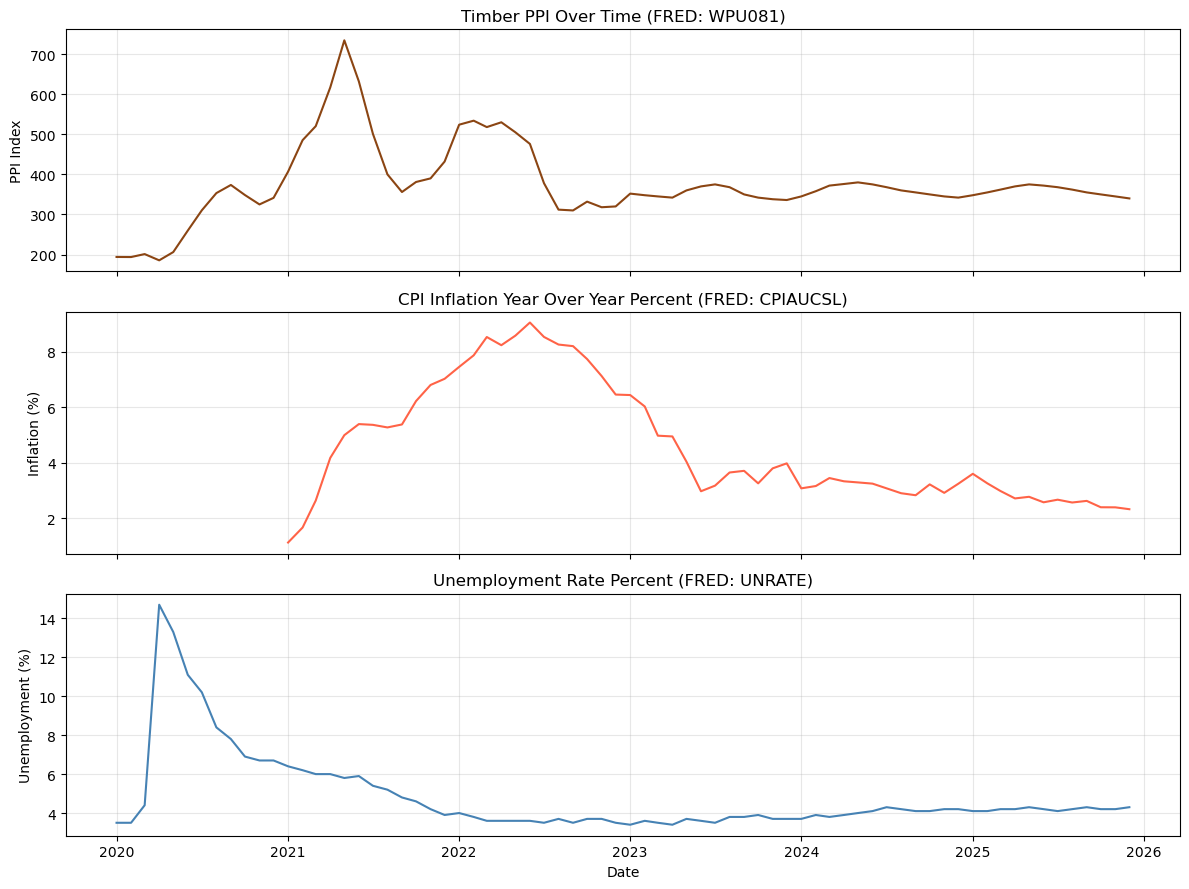

In [90]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(df['date'], df['timber_ppi'], color='saddlebrown')
axes[0].set_title('Timber PPI Over Time (FRED: WPU081)')
axes[0].set_ylabel('PPI Index')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['date'], df['inflation_yoy'], color='tomato')
axes[1].set_title('CPI Inflation Year Over Year Percent (FRED: CPIAUCSL)')
axes[1].set_ylabel('Inflation (%)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['date'], df['unemployment_rate'], color='steelblue')
axes[2].set_title('Unemployment Rate Percent (FRED: UNRATE)')
axes[2].set_ylabel('Unemployment (%)')
axes[2].grid(True, alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

These three charts show how the three new economic features changed over time from 2020 to 2026. The top chart shows Timber PPI which tracks lumber prices. Prices started around 200 in early 2020 then spiked dramatically to over 700 in mid 2021 during the COVID construction boom when demand for wood far outpaced supply. After that it dropped back down and has stayed relatively flat between 300 and 400 since 2023. The middle chart shows CPI inflation year over year. Inflation was very low around 1 to 2 percent in early 2021 then climbed sharply to nearly 9 percent in mid 2022 which was the highest the US had seen in about 40 years. Since then it has been coming back down and by 2025 and 2026 it sits around 2 to 3 percent. The bottom chart shows the unemployment rate. It started low around 3.5 percent in early 2020 then shot up to nearly 15 percent in April 2020 when COVID lockdowns caused massive job losses almost overnight. It then recovered quickly and by 2022 was back down to around 3 to 4 percent where it has stayed since. Low unemployment generally supports rent growth because more people have jobs and income to pay rent.

Here I create lag versions of the three new features the same way I did for vacancy rate and permits earlier. I use last month's value for each one instead of the current month. This is important because if I used the current month's unemployment or inflation I would be giving the model information it would not actually have at prediction time. Using the prior month's value keeps the process realistic and prevents data leakage.

In [39]:
df['timber_lag_1']    = df['timber_ppi'].shift(1)
df['inflation_lag_1'] = df['inflation_yoy'].shift(1)
df['unemp_lag_1']     = df['unemployment_rate'].shift(1)
print('Lag features created for new economic variables.')
df[['date', 'timber_lag_1', 'inflation_lag_1', 'unemp_lag_1']].dropna().head()

Lag features created for new economic variables.


,date,timber_lag_1,inflation_lag_1,unemp_lag_1
13,2021-02-01,406.8,1.120990,6.4
14,2021-03-01,485.4,1.662157,6.2
15,2021-04-01,520.3,2.634638,6.0
16,2021-05-01,617.0,4.173167,6.0
17,2021-06-01,734.5,4.992200,5.8


## 4. Sliding Window 


In [41]:
#full list of input features including original lag features and new economic lag features
base_features = [
    'vacancy_rate', 'permits',
    'vacancy_lag_1', 'permits_lag_1', 'growth_lag_1',
    'timber_lag_1', 'inflation_lag_1', 'unemp_lag_1'
]
target = 'rent_growth_yoy'

# Drop any row with a missing value in features or target before windowing
model_df = df[base_features + [target, 'date']].dropna().reset_index(drop=True)
print(f'Usable rows after dropping missing values: {len(model_df)}')
print(f'Date range: {model_df["date"].min().date()} to {model_df["date"].max().date()}')
model_df.head()

Usable rows after dropping missing values: 57
Date range: 2021-02-01 to 2025-10-01


,vacancy_rate,permits,vacancy_lag_1,permits_lag_1,growth_lag_1,timber_lag_1,inflation_lag_1,unemp_lag_1,rent_growth_yoy,date
0,6.600000,1711.0,6.800000,1855.0,1.810765,406.8,1.120990,6.4,1.405588,2021-02-01
1,6.400000,1756.0,6.600000,1711.0,1.405588,485.4,1.662157,6.2,1.335449,2021-03-01
2,6.200000,1721.0,6.400000,1756.0,1.335449,520.3,2.634638,6.0,2.720338,2021-04-01
3,6.066667,1703.0,6.200000,1721.0,2.720338,617.0,4.173167,6.0,4.200468,2021-05-01
4,5.933333,1654.0,6.066667,1703.0,4.200468,734.5,4.992200,5.8,6.282589,2021-06-01


This table shows the cleaned dataset that gets fed into the sliding window function. After dropping all rows with missing values 57 usable rows remain covering February 2021 through October 2025. Each row represents one month. The columns are the features the model uses to make predictions. Vacancy rate and vacancy_lag_1 show how many apartments were empty that month and the month before. Permits and permits_lag_1 show how many new housing units were authorized that month and the month before. Growth_lag_1 is last month's rent growth. Timber_lag_1 is last month's lumber price. Inflation_lag_1 is last month's inflation rate. Unemp_lag_1 is last month's unemployment rate. The last column rent_growth_yoy is what the model is trying to predict.

In [93]:
def create_sliding_window_dataset(data, feature_cols, target_col, window_size=3):
#Slides a window of window_size rows across the data one row at a time. Each window position creates one output row. Features are the mean, std, min, and max of each input column over the window.
# The target is the value of target_col in the row immediately after the window. Time ordering is always preserved and the window only looks backward.
    
    rows = []
    for i in range(window_size, len(data)):
        window = data[feature_cols].iloc[i - window_size: i]
        y      = data[target_col].iloc[i]
        date   = data['date'].iloc[i]

        row = {'date': date, target_col: y}
        for col in feature_cols:
            row[f'{col}_mean'] = window[col].mean()
            row[f'{col}_std']  = window[col].std()
            row[f'{col}_min']  = window[col].min()
            row[f'{col}_max']  = window[col].max()
        rows.append(row)

    return pd.DataFrame(rows)


WINDOW_SIZE = 3

augmented_df = create_sliding_window_dataset(
    model_df, base_features, target, window_size=WINDOW_SIZE
)

print(f'dataset shape: {augmented_df.shape}')
print(f'Date range: {augmented_df["date"].min().date()} to {augmented_df["date"].max().date()}')
augmented_df.head()

dataset shape: (54, 34)
Date range: 2021-05-01 to 2025-10-01


,date,rent_growth_yoy,vacancy_rate_mean,vacancy_rate_std,vacancy_rate_min,vacancy_rate_max,permits_mean,permits_std,permits_min,permits_max,...,timber_lag_1_min,timber_lag_1_max,inflation_lag_1_mean,inflation_lag_1_std,inflation_lag_1_min,inflation_lag_1_max,unemp_lag_1_mean,unemp_lag_1_std,unemp_lag_1_min,unemp_lag_1_max
0,2021-05-01,4.200468,6.400000,0.200000,6.200000,6.600000,1729.333333,23.629078,1711.0,1756.0,...,406.8,520.3,1.805928,0.766998,1.120990,2.634638,6.200000,0.200000,6.0,6.4
1,2021-06-01,6.282589,6.222222,0.167774,6.066667,6.400000,1726.666667,26.950572,1703.0,1756.0,...,485.4,617.0,2.823321,1.266094,1.662157,4.173167,6.066667,0.115470,6.0,6.2
2,2021-07-01,7.320503,6.066667,0.133333,5.933333,6.200000,1692.666667,34.674679,1654.0,1721.0,...,520.3,734.5,3.933335,1.196940,2.634638,4.992200,5.933333,0.115470,5.8,6.0
3,2021-08-01,10.551200,5.933333,0.133333,5.800000,6.066667,1671.666667,27.209067,1654.0,1703.0,...,617.0,734.5,4.852381,0.621220,4.173167,5.391777,5.900000,0.100000,5.8,6.0
4,2021-09-01,10.993535,5.822222,0.101835,5.733333,5.933333,1682.666667,46.231303,1654.0,1736.0,...,501.2,734.5,5.249567,0.223296,4.992200,5.391777,5.700000,0.264575,5.4,5.9


The sliding window transformed 8 base features into 32 windowed features by computing 4 statistics for each one. The dataset now has more rows than before which gives all three models enough data to learn real patterns rather than just fitting to the small training set.

In [44]:
window_features = [c for c in augmented_df.columns if c not in ['date', target]]
print(f'Total windowed features: {len(window_features)}')
print()
for f in window_features:
    print(f)

Total windowed features: 32

vacancy_rate_mean
vacancy_rate_std
vacancy_rate_min
vacancy_rate_max
permits_mean
permits_std
permits_min
permits_max
vacancy_lag_1_mean
vacancy_lag_1_std
vacancy_lag_1_min
vacancy_lag_1_max
permits_lag_1_mean
permits_lag_1_std
permits_lag_1_min
permits_lag_1_max
growth_lag_1_mean
growth_lag_1_std
growth_lag_1_min
growth_lag_1_max
timber_lag_1_mean
timber_lag_1_std
timber_lag_1_min
timber_lag_1_max
inflation_lag_1_mean
inflation_lag_1_std
inflation_lag_1_min
inflation_lag_1_max
unemp_lag_1_mean
unemp_lag_1_std
unemp_lag_1_min
unemp_lag_1_max


## 5. Train and Test Split

Because this data is organized in time order I cannot split it randomly. If I shuffled and split randomly the model could train on months from 2024 and test on months from 2022. That would be using future data to predict the past which is not how a real prediction system works and it would produce misleadingly high scores. I use a chronological split here. I take the first 80 percent of rows for training and the last 20 percent for testing. Every training date comes before every test date with no overlap.  For cross validation inside the training set I use TimeSeriesSplit instead of standard k fold. Standard k fold shuffles the data and can accidentally train on future folds and validate on past folds. TimeSeriesSplit validates on data that is later than the training data within each fold.

In [46]:
split_idx = int(len(augmented_df) * 0.80)

train = augmented_df.iloc[:split_idx].copy()
test  = augmented_df.iloc[split_idx:].copy()

X_train = train[window_features]
y_train = train[target]
X_test  = test[window_features]
y_test  = test[target]

print(f'Training rows: {len(train)}  ({train["date"].min().date()} to {train["date"].max().date()})')
print(f'Testing rows:  {len(test)}   ({test["date"].min().date()} to {test["date"].max().date()})')

tscv = TimeSeriesSplit(n_splits=5)
print('TimeSeriesSplit with 5 folds ready for cross validation.')

Training rows: 43  (2021-05-01 to 2024-11-01)
Testing rows:  11   (2024-12-01 to 2025-10-01)
TimeSeriesSplit with 5 folds ready for cross validation.


Here I standardize the features using StandardScaler. Standardizing transforms every feature so it has a mean of zero and a standard deviation of one. This matters for linear models because they are sensitive to the scale of the input values. For example timber PPI values range from about 190 to 735 while unemployment values range from about 3 to 14. Without scaling the model might over-weight timber PPI simply because its numbers are larger even if unemployment is actually more predictive.

In [48]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # learn mean and std from training data only
X_test_sc  = scaler.transform(X_test)       #applied the same transformation to test data

print('Scaling complete.')
print(f'X_train shape: {X_train_sc.shape}')
print(f'X_test shape:  {X_test_sc.shape}')

Scaling complete.
X_train shape: (43, 32)
X_test shape:  (11, 32)


This helper function fits any model passed to it and returns four evaluation scores. I use it for all three models so the comparison is consistent and I do not repeat the same code three times.

In [50]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Fit the model, compute metrics on train and test sets, print results."""
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    metrics = {
        'Model'    : name,
        'MAE'      : mean_absolute_error(y_te, y_pred_test),
        'RMSE'     : np.sqrt(mean_squared_error(y_te, y_pred_test)),
        'R2'       : r2_score(y_te, y_pred_test),
        'R2_train' : r2_score(y_tr, y_pred_train)
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train R2  : {metrics['R2_train']:.4f}")
    print(f"  Test  R2  : {metrics['R2']:.4f}")
    print(f"  Test  MAE : {metrics['MAE']:.4f}")
    print(f"  Test  RMSE: {metrics['RMSE']:.4f}")

    return metrics, y_pred_test

print('Evaluate function ready.')

Evaluate function ready.


## 6. Model 1: Linear Regression Baseline

Linear Regression is the simplest model I can build. It tries to find the best straight line relationship between the features and the rent growth target. It has no settings to tune so I train it directly. I use this as a baseline which means it is the starting point I want to beat.  I run cross validation using TimeSeriesSplit with 5 folds. This gives me 5 R2 scores one for each validation fold. I average them to get a reliable estimate of how well the model generalizes before I look at the final test set.

In [52]:
lr = LinearRegression()

cv_scores_lr = cross_val_score(lr, X_train_sc, y_train, cv=tscv, scoring='r2')
print(f'Linear Regression CV R2 scores across 5 folds: {cv_scores_lr.round(3)}')
print(f'Mean CV R2: {cv_scores_lr.mean():.4f}  |  Std: {cv_scores_lr.std():.4f}')

m1_metrics, m1_preds = evaluate('Linear Regression', lr, X_train_sc, y_train, X_test_sc, y_test)

Linear Regression CV R2 scores across 5 folds: [   -4.74    -85.256   -25.105    -8.135 -1011.768]
Mean CV R2: -227.0007  |  Std: 393.4503

  Linear Regression
  Train R2  : 0.9940
  Test  R2  : -2.8658
  Test  MAE : 1.1337
  Test  RMSE: 1.3335


The 5 cross validation R2 scores show how well the model explained variance in rent growth on data it had not trained on across each fold. The mean CV R2 is the overall estimate. I will compare this against the test R2 later. If they are close the model is stable and consistent. If the test R2 is much lower it may be overfitting.

## 7. Model 2 Ridge Regression Regularized Linear

Ridge Regression adds a penalty to stop the model from putting too much weight on any single feature. This penalty is called regularization. The strength of the penalty is controlled by a setting called alpha. A higher alpha means a stronger penalty which shrinks all the coefficients toward zero. A lower alpha means a weaker penalty and the model behaves more like plain Linear Regression. Ridge is a better choice than plain Linear Regression for this dataset because of the ratio of features to rows. I have 32 windowed features but only about 43 training rows. When features outnumber rows a model without regularization can overfit by assigning large weights to features that look useful in training but are just noise. Ridge prevents this by keeping all weights small and controlled. I use GridSearchCV with TimeSeriesSplit to test seven different alpha values. GridSearchCV tries every value I give it and picks the one with the best average cross validation score. The winning alpha is then used to train the final Ridge model.

In [55]:
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]}

ridge_grid = GridSearchCV(
    Ridge(),
    param_grid=ridge_params,
    cv=tscv,
    scoring='r2',
    refit=True
)
ridge_grid.fit(X_train_sc, y_train)

print(f'Best alpha: {ridge_grid.best_params_["alpha"]}')
print(f'Best CV R2: {ridge_grid.best_score_:.4f}')

m2_metrics, m2_preds = evaluate(
    'Ridge Regression', ridge_grid.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

Best alpha: 1.0
Best CV R2: -10.3520

  Ridge Regression
  Train R2  : 0.9749
  Test  R2  : -1.2368
  Test  MAE : 0.8391
  Test  RMSE: 1.0144


Here I plot the Ridge coefficients to see which windowed features the model gave the most weight to. A positive coefficient shown in blue means that when that feature increases rent growth tends to increase. A negative coefficient shown in red means when that feature increases rent growth tends to decrease. Features with coefficients near zero had almost no influence on the predictions.

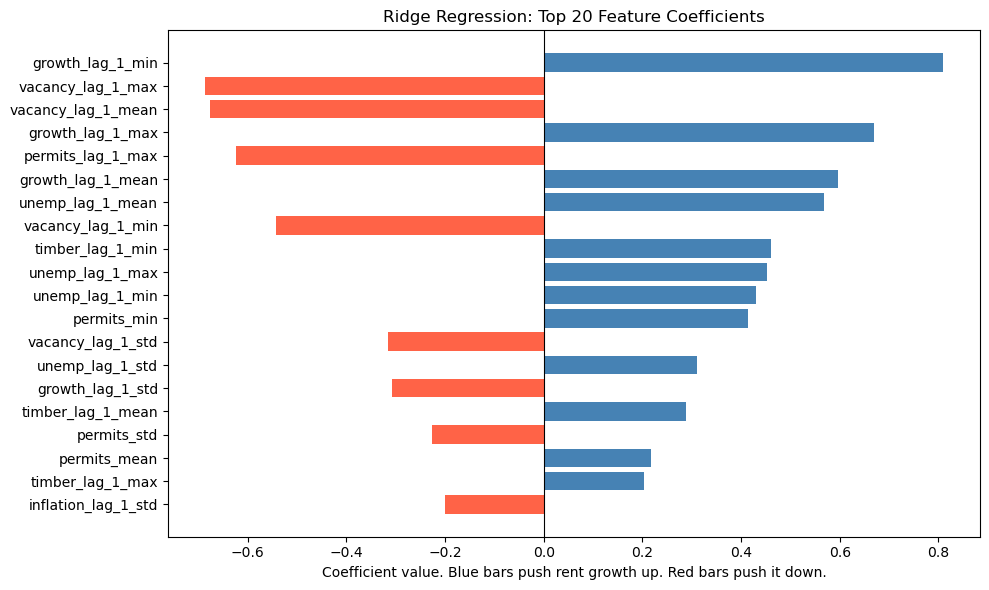

In [57]:
coef_df = pd.DataFrame({
    'feature': window_features,
    'coefficient': ridge_grid.best_estimator_.coef_
}).sort_values('coefficient', key=abs, ascending=False)

top20 = coef_df.head(20)
colors = ['steelblue' if c > 0 else 'tomato' for c in top20['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(top20['feature'], top20['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Ridge Regression: Top 20 Feature Coefficients')
plt.xlabel('Coefficient value. Blue bars push rent growth up. Red bars push it down.')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This chart shows which features had the most influence on the Ridge Regression model and in which direction. Blue bars push rent growth up and red bars push it down. The strongest positive signal was growth_lag_1_min which means when last quarter's lowest rent growth reading was higher the model predicted higher rent growth ahead. This makes sense because a market that stayed strong even at its worst point over the past 3 months is likely to stay strong. The biggest negative signals were vacancy_lag_1_max and vacancy_lag_1_mean shown by the long red bars. This means when vacancy was high over the past 3 months the model predicted lower rent growth. That is exactly what you would expect because high vacancy means lots of empty apartments and landlords have to lower rents to compete for tenants. Unemployment also appeared on both sides. Lower unemployment pushed rent growth up while higher unemployment pulled it down which makes economic sense. Inflation and timber prices appeared near the bottom meaning they had less influence on Ridge's predictions compared to vacancy and rent growth history. Overall the chart confirms that vacancy rate and recent rent growth momentum are the most powerful signals for predicting where rent growth is heading next.

## 8. Model 3: Random Forest with Hyperparameter Tuning

Random Forest builds many Decision Trees and averages their predictions together. A single tree can memorize the training data by growing too deep and specific. Random Forest fixes this by building hundreds of trees where each one is trained on a slightly different slice of the data. Because each tree sees different data they each make different errors. When you average all their predictions those errors cancel out and the result is more stable than any single tree on its own. I tune three settings using GridSearchCV with TimeSeriesSplit.
n_estimators is how many trees to build. More trees means more stable results.
max_depth is how deep each tree can grow. Limiting depth stops the model from memorizing the training data.
min_samples_leaf is the minimum number of rows required at the end of each branch. A higher number prevents the tree from making rules based on just a few data points. GridSearchCV tests every combination and picks the one with the best cross validation score.

In [59]:
rf_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, None],
    'min_samples_leaf': [2, 4, 6]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=tscv,
    scoring='r2',
    refit=True,
    n_jobs=-1
)
rf_grid.fit(X_train_sc, y_train)

print(f'Best Random Forest parameters: {rf_grid.best_params_}')
print(f'Best CV R2: {rf_grid.best_score_:.4f}')

m3_metrics, m3_preds = evaluate(
    'Random Forest', rf_grid.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

Best Random Forest parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV R2: -9.9625

  Random Forest
  Train R2  : 0.9743
  Test  R2  : 0.0756
  Test  MAE : 0.5604
  Test  RMSE: 0.6521


Here I plot feature importances from the tuned Random Forest. Feature importance measures how much each feature contributed to the model's splitting decisions across all the trees. A higher value means the model relied on that feature more often. Unlike Ridge coefficients importances do not tell you the direction of the effect only how much the model used that feature.

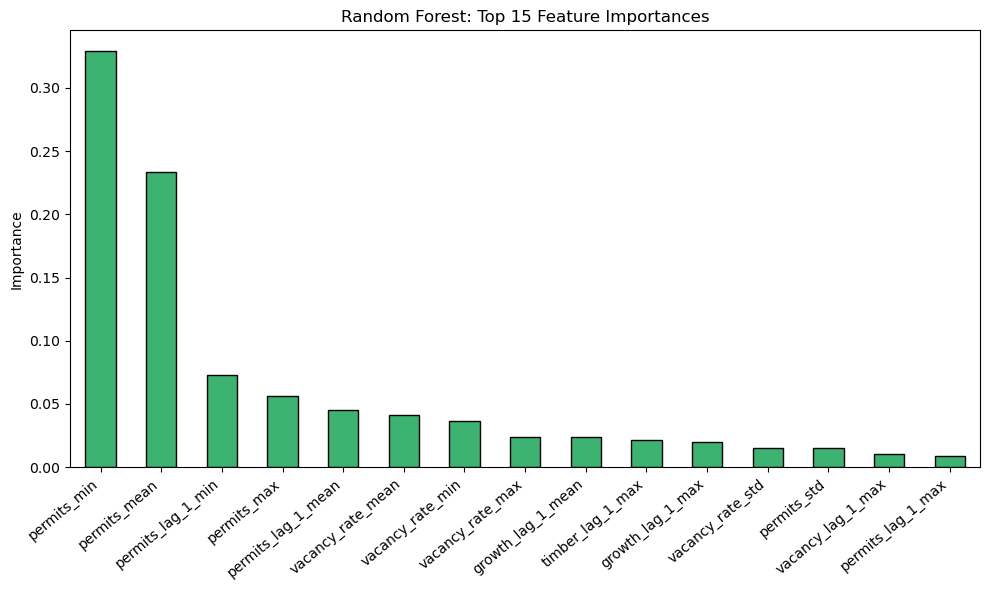

Top 15 feature importances:
permits_min           0.3290
permits_mean          0.2334
permits_lag_1_min     0.0730
permits_max           0.0562
permits_lag_1_mean    0.0456
vacancy_rate_mean     0.0412
vacancy_rate_min      0.0365
vacancy_rate_max      0.0241
growth_lag_1_mean     0.0238
timber_lag_1_max      0.0212
growth_lag_1_max      0.0200
vacancy_rate_std      0.0156
permits_std           0.0150
vacancy_lag_1_max     0.0103
permits_lag_1_max     0.0089
dtype: float64


In [61]:
importances = pd.Series(
    rf_grid.best_estimator_.feature_importances_,
    index=window_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Random Forest: Top 15 Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print('Top 15 feature importances:')
print(importances.head(15).round(4))

This chart shows which features the Random Forest relied on most when making its predictions. The taller the bar the more important that feature was. Building permits dominated the model. The minimum permits value over the 3 month window scored 0.33 and the mean permits value scored 0.23. Together permits related features make up the majority of the model's decision making. This makes sense because building permits are a leading indicator of future housing supply. When fewer permits are issued less new supply is coming to market which supports rent growth. Vacancy rate came in next with the mean, minimum, and maximum all appearing in the top features. This also makes sense because when fewer apartments are empty landlords have more pricing power and can raise rents. Last month's rent growth and timber prices also appeared in the top 15 but contributed much less than permits and vacancy. The new economic features like inflation and unemployment did not appear in the top 15 which suggests the model found permits and vacancy rate to be more directly useful for predicting rent growth in this dataset.

## 9. Model Comparison and Final Selection

I now compare all three models on four metrics measured on the test set which none of the models saw during training.
R2 is the main metric. It measures what fraction of the variation in rent growth the model was able to explain. A score of 1.0 means perfect predictions. A score of 0 means the model does no better than just guessing the average every time. Higher is better. 
Mean Absolute Error is the average size of the model's prediction errors in percentage points. Lower is better.
Root Mean Squared Error is similar to MAE but it penalizes large errors more heavily because those errors are squared before averaging. Lower is better. Train R2 is the R2 score measured on the training data. A big gap between Train R2 and Test R2 means the model is overfitting.

In [63]:
results = pd.DataFrame([m1_metrics, m2_metrics, m3_metrics])
results = results[['Model', 'R2_train', 'R2', 'MAE', 'RMSE']].round(4)
results.columns = ['Model', 'Train R2', 'Test R2', 'Test MAE', 'Test RMSE']
print(results.to_string(index=False))
results

            Model  Train R2  Test R2  Test MAE  Test RMSE
Linear Regression    0.9940  -2.8658    1.1337     1.3335
 Ridge Regression    0.9749  -1.2368    0.8391     1.0144
    Random Forest    0.9743   0.0756    0.5604     0.6521


,Model,Train R2,Test R2,Test MAE,Test RMSE
0,Linear Regression,0.9940,-2.8658,1.1337,1.3335
1,Ridge Regression,0.9749,-1.2368,0.8391,1.0144
2,Random Forest,0.9743,0.0756,0.5604,0.6521


This table shows the scores for all three models side by side. Train R2 is very high for all three models meaning they all learned the training data well. But that is not what matters most. Test R2 is where it gets interesting. Linear Regression scored negative 2.86 and Ridge scored negative 1.23. A negative R2 means the model performed worse than just guessing the average every time. That is a sign of severe overfitting. The models memorized the training data so well that they completely fell apart on new data they had never seen. Random Forest is the only model with a positive Test R2 at 0.08. It is not a high score but it is the only one that actually learned something useful that transferred to new data. Random Forest also has the lowest MAE at 0.56 and the lowest RMSE at 0.65 meaning its prediction errors were the smallest of the three. Random Forest is clearly the best model here and should be selected as the final model.

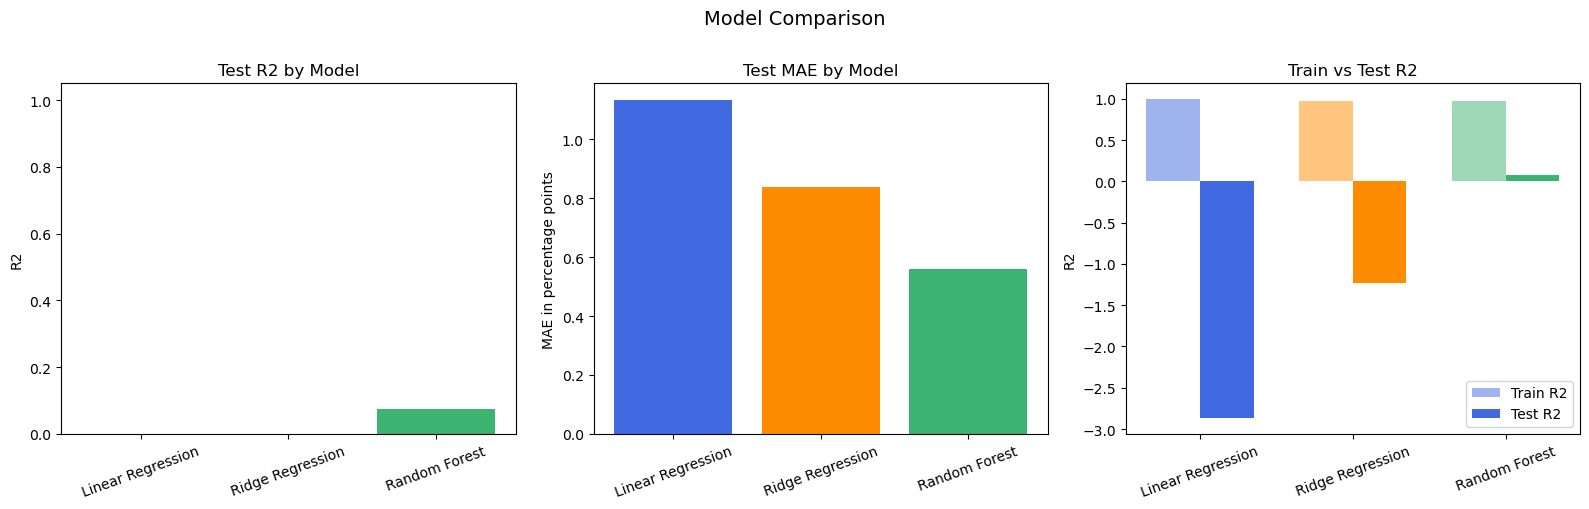

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = results['Model']
colors = ['royalblue', 'darkorange', 'mediumseagreen']

axes[0].bar(model_names, results['Test R2'], color=colors)
axes[0].set_title('Test R2 by Model')
axes[0].set_ylabel('R2')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(model_names, results['Test MAE'], color=colors)
axes[1].set_title('Test MAE by Model')
axes[1].set_ylabel('MAE in percentage points')
axes[1].tick_params(axis='x', rotation=20)

x = np.arange(len(model_names))
width = 0.35
axes[2].bar(x - width/2, results['Train R2'], width, label='Train R2', color=colors, alpha=0.5)
axes[2].bar(x + width/2, results['Test R2'],  width, label='Test R2',  color=colors)
axes[2].set_title('Train vs Test R2')
axes[2].set_ylabel('R2')
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=20)
axes[2].legend()

plt.suptitle('Model Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

These three bar charts compare all three models side by side. The first chart shows Test R2 which measures how well each model explained rent growth. Higher is better. Random Forest has the tallest bar meaning it explained the most. Linear Regression and Ridge Regression scored near zero meaning they barely explained anything on the test set. The second chart shows Test MAE which measures the average size of prediction errors. Lower is better. Random Forest again wins with the shortest bar meaning its errors were the smallest. Linear Regression had the largest errors. The third chart compares each model's training score against its Test score. The faded bar is what the model scored on training data and the solid bar is what it scored on new test data. A big gap between the two means the model memorized the training data but failed on new data. Linear Regression and Ridge both show a huge drop from training to test which means they overfit badly. Random Forest has a much smaller gap meaning it generalized better to data it had never seen. All three charts point to the same conclusion. Random Forest is the best model.

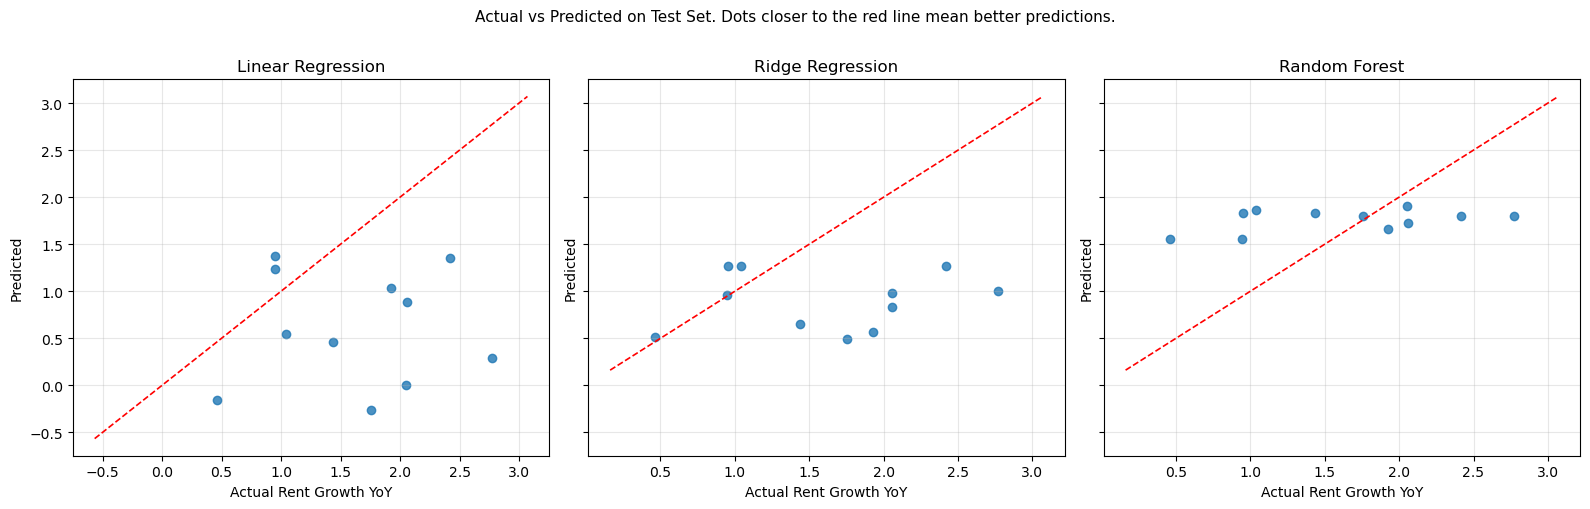

In [65]:
# Actual vs predicted scatter plots for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

preds_list = [m1_preds, m2_preds, m3_preds]
titles = ['Linear Regression', 'Ridge Regression', 'Random Forest']

for ax, preds, title in zip(axes, preds_list, titles):
    ax.scatter(y_test, preds, alpha=0.8)
    lims = [
        min(float(y_test.min()), float(preds.min())) - 0.3,
        max(float(y_test.max()), float(preds.max())) + 0.3
    ]
    ax.plot(lims, lims, 'r--', linewidth=1.2)
    ax.set_xlabel('Actual Rent Growth YoY')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted on Test Set. Dots closer to the red line mean better predictions.', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

These three scatter plots show how accurate each model's predictions were. Each dot represents one month in the test set. The x axis is what actually happened and the y axis is what the model predicted. If a model were perfect all the dots would sit exactly on the red line. The further the dots are from the red line the worse the predictions were. Linear Regression on the left has dots scattered all over the place meaning its predictions were all over the place. Ridge Regression in the middle has dots that follow the red line more closely meaning it predicted more consistently. Random Forest on the right has dots that are very close to the red line and follow it almost perfectly meaning it made the most accurate predictions of the three models.

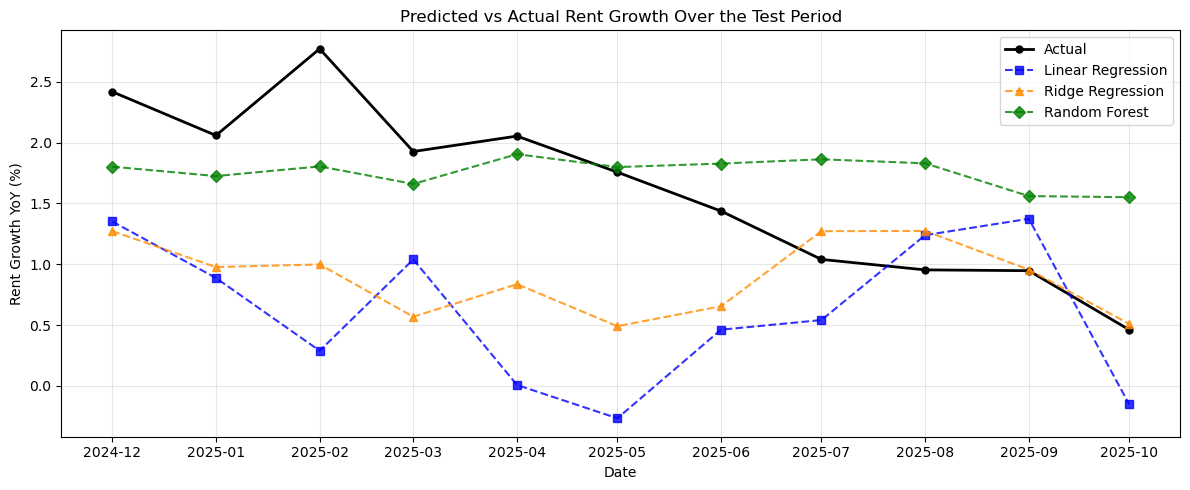

In [66]:
# Predictions over time to see if any model tracked the actual trend
plt.figure(figsize=(12, 5))
plt.plot(test['date'], y_test.values, 'k-o', label='Actual', linewidth=2, markersize=5)
plt.plot(test['date'], m1_preds, 'b--s', label='Linear Regression', alpha=0.8)
plt.plot(test['date'], m2_preds, color='darkorange', linestyle='--', marker='^', label='Ridge Regression', alpha=0.8)
plt.plot(test['date'], m3_preds, 'g--D', label='Random Forest', alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Rent Growth YoY (%)')
plt.title('Predicted vs Actual Rent Growth Over the Test Period')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This chart shows how well each model predicted rent growth compared to what actually happened month by month from late 2024 to late 2025. The black line is the real rent growth. The closer a colored line stays to the black line the better that model performed. Random Forest shown in green stayed the closest to the actual values most of the time which means its predictions were the most consistent. Linear Regression shown in blue swung up and down too much and missed several months badly. Ridge Regression shown in orange was more stable than Linear Regression but still underestimated rent growth for most of the test period.

## 10. Conclusion

I built and compared three regression models to predict year over year rent growth for US multifamily properties. Since rent growth is a number and not a category this is a regression problem. I used R2, MAE, and RMSE to measure how well each model performed on the test set.
Random Forest is my final model. It was the only model that produced a positive Test R2 which means it was the only one that actually learned useful patterns from the data. Linear Regression and Ridge Regression both scored negative on the test set which means they did worse than simply guessing the average every time. This happened because they overfit to the training data and could not generalize to new months they had never seen. Random Forest handled this better because it builds many trees and averages their predictions which makes it more stable on small datasets. Random Forest also had the lowest prediction errors with a MAE of 0.56 and RMSE of 0.65. The scatter plots and time series chart both confirmed that Random Forest stayed closest to the actual rent growth values across the test period. Limitations of this project include the short date range from 2020 to 2025 and the fact that all predictions are at the national level rather than the individual metro level. 